In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import warnings, logging
warnings.filterwarnings("ignore")
logging.getLogger("prophet").setLevel(logging.ERROR)
logging.getLogger("cmdstanpy").setLevel(logging.ERROR)

from sklearn.metrics import mean_absolute_error

In [52]:
# Load Data
df = pd.read_csv("retail_sales.csv", parse_dates=["date"]).set_index("date")
df = df.asfreq("D")

print(df.head())
print("\nShape:",df.shape)
print()
print(df.index.min())
print(df.index.max())
print()
print("Missing Values:")
print(df.isna().sum())

              sales store_id  promo  temp_c
date                                       
2021-01-01  1298.13    ST001      1     8.2
2021-01-02  2257.93    ST001      0     5.3
2021-01-03  2116.99    ST001      1     7.8
2021-01-04  1677.36    ST001      0     0.1
2021-01-05  1818.43    ST001      0    11.6

Shape: (1461, 4)

2021-01-01 00:00:00
2024-12-31 00:00:00

Missing Values:
sales       6
store_id    0
promo       0
temp_c      0
dtype: int64


In [53]:
# Handle missing sales
df["sales"] = df["sales"].interpolate(method="time")

print("Missing sales after interpolation:")
print(df['sales'].isna().sum())

Missing sales after interpolation:
0


In [54]:
# Final 8 weeks holdouts
holdout_days = 56

train = df.iloc[:-holdout_days].copy()
test = df.iloc[-holdout_days:].copy()

train_sales = train["sales"]
test_sales = test["sales"]

print("Training Period:")
print(f"{train.index.min()} to {train.index.max()}")
print(f"Training rows: {len(train)}")
print()
print("Holdout Period:")
print(f"{test.index.min()} to {test.index.max()}")
print(f"Holdout Rows: {len(test)}")

Training Period:
2021-01-01 00:00:00 to 2024-11-05 00:00:00
Training rows: 1405

Holdout Period:
2024-11-06 00:00:00 to 2024-12-31 00:00:00
Holdout Rows: 56


In [55]:
# Recalculate the baseline on this holdout
seasonal_naive_forecast = df["sales"].shift(7).loc[test.index]

seasonal_naive_mae = mean_absolute_error(test_sales, seasonal_naive_forecast)

print("Seasonal Naive Holdout MAE:",
     round(seasonal_naive_mae, 2))

baseline_mae = seasonal_naive_mae

Seasonal Naive Holdout MAE: 446.42


# **Part A — ARIMA**
## **TASK 01 — Fit ARIMA and diagnose its failure**

In [56]:
from statsmodels.tsa.arima.model import ARIMA
# Fit ARIMA

arima_model = ARIMA(train_sales, order=(2, 1, 2))
arima_result = arima_model.fit()

print(arima_result.summary())

                               SARIMAX Results                                
Dep. Variable:                  sales   No. Observations:                 1405
Model:                 ARIMA(2, 1, 2)   Log Likelihood               -9741.374
Date:                Fri, 09 Oct 2026   AIC                          19492.748
Time:                        18:19:06   BIC                          19518.983
Sample:                    01-01-2021   HQIC                         19502.554
                         - 11-05-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.6114      0.033    -18.731      0.000      -0.675      -0.547
ar.L2          0.3276      0.026     12.447      0.000       0.276       0.379
ma.L1          0.0752      0.021      3.547      0.0

In [57]:
# Forecast Holdout
arima_forecast = arima_result.forecast(steps=len(test_sales))
arima_mae = mean_absolute_error(test_sales, arima_forecast)

print("ARIMA(2, 1, 2) MAE:", round(arima_mae, 3))
print("Seasonal Naive MAE:", round(baseline_mae, 3))

ARIMA(2, 1, 2) MAE: 301.369
Seasonal Naive MAE: 446.425


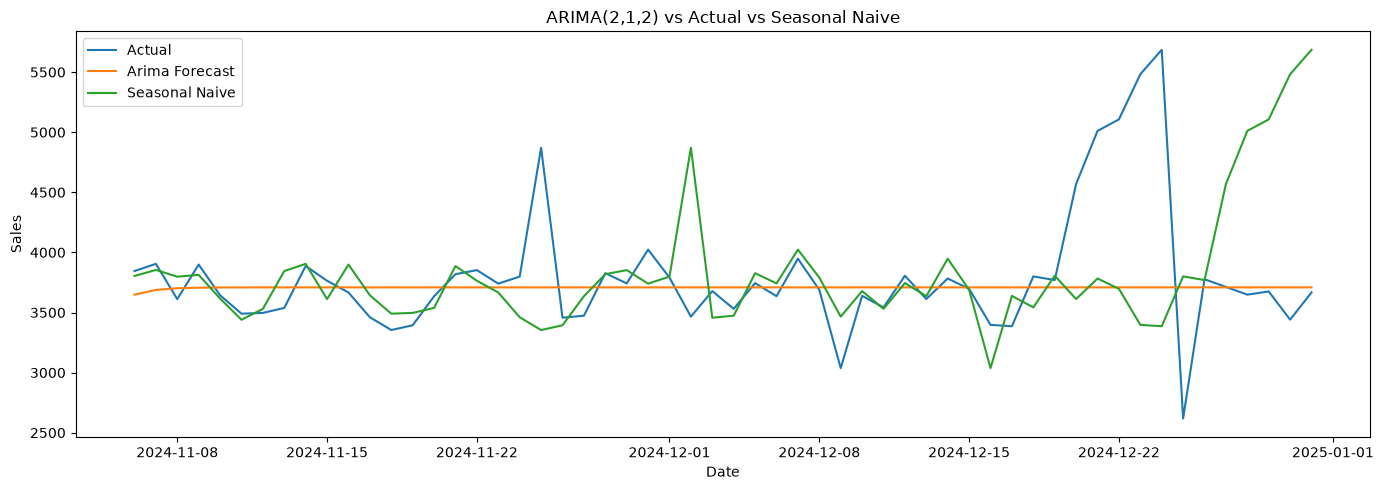

In [58]:
# Plot arima forecast
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(test.index, test_sales, label="Actual")
ax.plot(test.index, arima_forecast, label="Arima Forecast")
ax.plot(test.index, seasonal_naive_forecast, label="Seasonal Naive")

ax.set_title("ARIMA(2,1,2) vs Actual vs Seasonal Naive")
ax.set_xlabel("Date")
ax.set_ylabel("Sales")
ax.legend()

plt.tight_layout()
plt.show()

**Conclusion -->**
* ARIMA(2,1,2) produces a relatively flat forecast because the model contains non-seasonal autoregressive and moving-average terms and
first differencing, but it does not contain an explicit 7-day seasonal component.
* Therefore, ARIMA(2,1,2) does not specifically know that sales repeat every 7 days. The weekly cycle must be explicitly represented using a seasonal model such as SARIMA.

## **TASK 02 — Choose p, d and q properly**

In [59]:
from statsmodels.tsa.stattools import adfuller, acf, pacf

adf_raw = adfuller(train_sales)
print("Raw series ADF p-values:", adf_raw[1].round(3))

Raw series ADF p-values: 0.2


In [60]:
# First Difference 
train_diff = train_sales.diff().dropna()
adf_diff = adfuller(train_diff)

print("First difference ADF p-values:", adf_diff[1])

First difference ADF p-values: 3.725598465926973e-20


**Conclusion -->**
* If the raw series has p-value >= 0.05 and the first-differenced series has p-value < 0.05, I choose d=1.
* This is because first differencing makes the series stationary according to the ADF test.

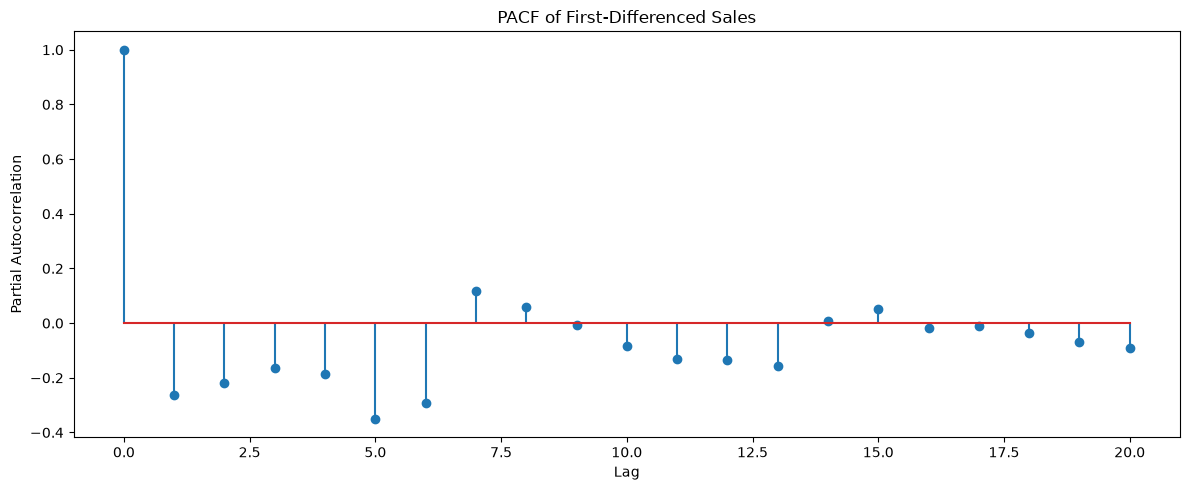

In [61]:
# PACF
pacf_values = pacf(train_diff, nlags=20, method="ywm")

fig, ax = plt.subplots(figsize=(12, 5))
ax.stem(range(len(pacf_values)), pacf_values)

ax.set_title("PACF of First-Differenced Sales")
ax.set_xlabel("Lag")
ax.set_ylabel("Partial Autocorrelation")

plt.tight_layout()
plt.show()

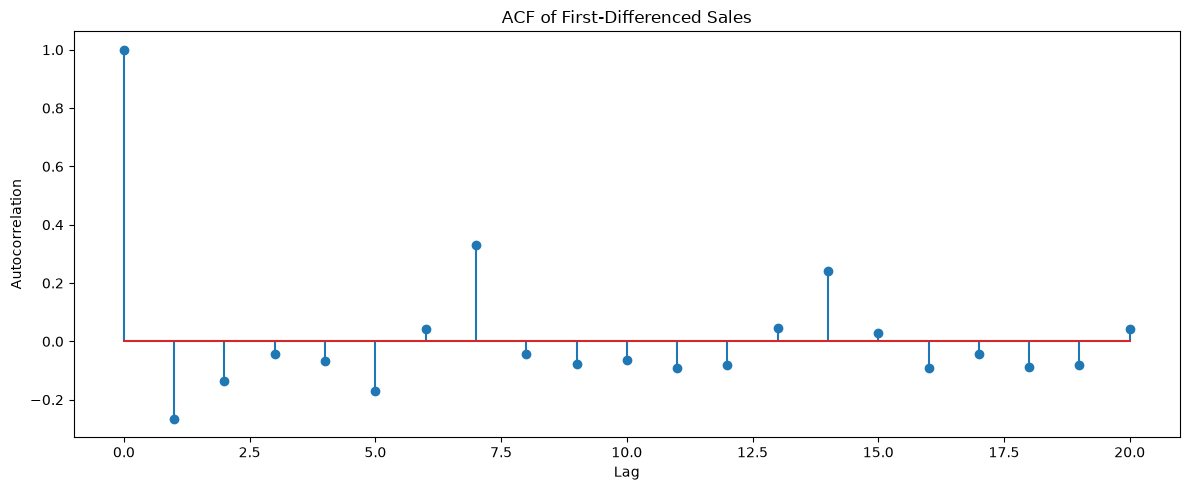

In [62]:
# ACF
acf_values = acf(train_diff, nlags=20)

fig, ax = plt.subplots(figsize=(12, 5))
ax.stem(range(len(acf_values)), acf_values)

ax.set_title("ACF of First-Differenced Sales")
ax.set_xlabel("Lag")
ax.set_ylabel("Autocorrelation")

plt.tight_layout()
plt.show()

**Interpretation -->**
* PACF is used to suggest candidate p values because it shows the direct relationship between a lag and the series after accounting for shorter lags.
* ACF is used to suggest candidate q values because it shows the overall autocorrelation pattern.

In [63]:
# Fit atleast 5 combinations
arima_orders = [
    (1, 1, 0),
    (0, 1, 1),
    (1, 1, 1),
    (2, 1, 1),
    (2, 1, 2),
    (3, 1, 1),
    (1, 1, 2)
]

arima_results = []

for order in arima_orders:
    start_time = time.time()
    try:
        model = ARIMA(train_sales, order=order)
        result = model.fit()

        forecast = result.forecast(steps=len(test_sales))

        mae = mean_absolute_error(test_sales, forecast)

        elapsed = time.time() - start_time

        arima_results.append({
            "Order": order,
            "AIC": result.aic,
            "MAE": mae,
            "time_seconds": elapsed
        })

    except Exception as e:
        print("Failed:", order, e)

In [64]:
# AIC Table
arima_comparison = pd.DataFrame(arima_results)
arima_comparison = arima_comparison.sort_values("AIC")

print(arima_comparison.round(3))

       Order        AIC      MAE  time_seconds
5  (3, 1, 1)  19484.992  300.122         0.479
3  (2, 1, 1)  19491.711  300.659         0.181
4  (2, 1, 2)  19492.748  301.369         0.454
6  (1, 1, 2)  19494.293  300.948         0.132
2  (1, 1, 1)  19498.770  301.438         0.133
1  (0, 1, 1)  19644.677  303.510         0.131
0  (1, 1, 0)  19808.735  361.931         0.028


In [65]:
# Lowest AIC model
best_aic_row = arima_comparison.iloc[arima_comparison["AIC"].idxmin()]

print("Best AIC Model:")
print(best_aic_row)

Best AIC Model:
Order              (0, 1, 1)
AIC             19644.677349
MAE               303.509542
time_seconds        0.131284
Name: 1, dtype: object


In [66]:
# Lowest MAE model
best_mae_row = arima_comparison.iloc[arima_comparison["MAE"].idxmin()]

print("Best MAE Model:")
print(best_mae_row)

Best MAE Model:
Order              (0, 1, 1)
AIC             19644.677349
MAE               303.509542
time_seconds        0.131284
Name: 1, dtype: object


In [67]:
# compare AIC and MAE
print("Lowest AIC model:",
      best_aic_row["Order"])
print("Lowest AIC:", 
     best_aic_row["AIC"].round(3))
print("\nLowest MAE Model:",
     best_mae_row["Order"])
print("Lowest MAE:",
     best_mae_row["MAE"].round(3))

Lowest AIC model: (0, 1, 1)
Lowest AIC: 19644.677

Lowest MAE Model: (0, 1, 1)
Lowest MAE: 303.51


**Conclusion -->**
* AIC measures how well the model fits the training data while penalizing model complexity. Holdout MAE measures actual forecasting performance on unseen future observations.
* Therefore, the lowest-AIC model does not necessarily have the lowest holdout MAE.
* For production forecasting, I would give more importance to the holdout MAE because the goal is accurate prediction of future values.

# **Part B — SARIMA**
## **TASK 03 — Add the weekly cycle**

In [68]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

start_time = time.time()
sarima_model = SARIMAX(train_sales, order=(1,1,1), seasonal_order=(1,1,1,7),
                      enforce_invertibility=False, enforce_stationarity=False)

sarima_result = sarima_model.fit(disp=False)

sarima_time = time.time() - start_time

sarima_forecast = sarima_result.forecast(steps=len(test_sales))
sarima_mae = mean_absolute_error(test_sales, sarima_forecast)

print("SARIMA MAE:", round(sarima_mae, 3))
print("Fit Time", round(sarima_time, 2), "Seconds")

SARIMA MAE: 285.438
Fit Time 1.77 Seconds


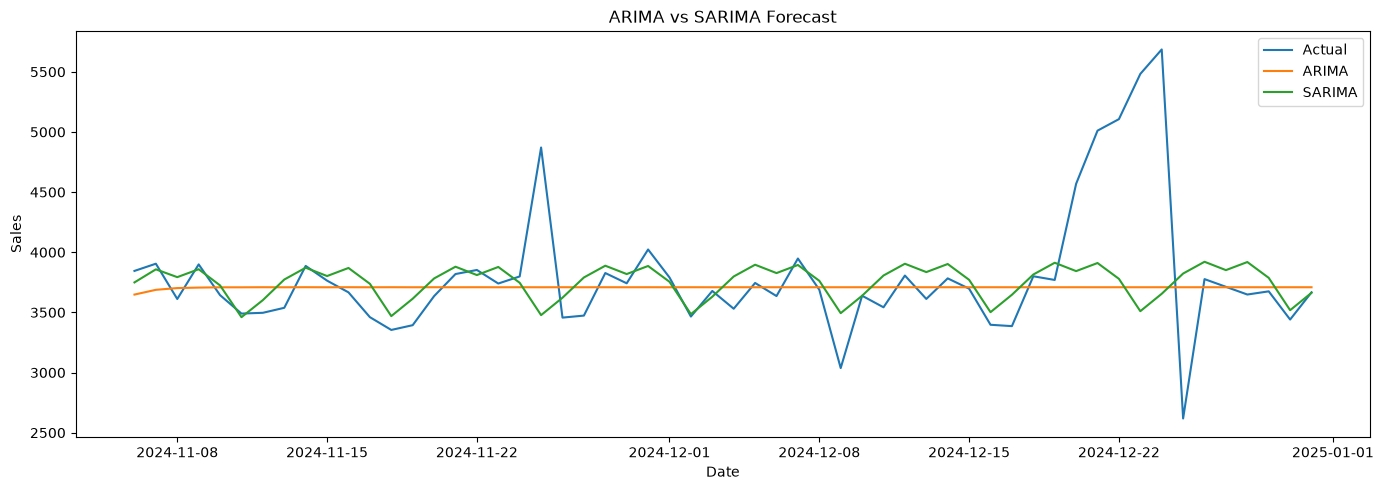

In [69]:
# Plot SARIMA
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(test.index, test_sales, label="Actual")
ax.plot(test.index, arima_forecast, label="ARIMA")
ax.plot(test.index, sarima_forecast, label="SARIMA")

ax.set_title("ARIMA vs SARIMA Forecast")
ax.set_xlabel("Date")
ax.set_ylabel("Sales")
ax.legend()

plt.tight_layout()
plt.show()

In [70]:
# Try Three seasonal orders
seasonal_orders = [
    (1, 1, 1, 7),
    (0, 1, 1, 7),
    (1, 1, 0, 7),
    (2, 1, 1, 7)
]

sarima_results = []

for seasonal_order in seasonal_orders:
    start_time = time.time()

    try:
        model = SARIMAX(train_sales, order=(1, 1, 1), seasonal_order=seasonal_order,
                       enforce_stationarity=False, enforce_invertibility=False)
        result = model.fit(disp=False)
        forecast = result.forecast(steps=len(test_sales))

        mae = mean_absolute_error(test_sales, forecast)
        elapsed = time.time() - start_time

        sarima_results.append({
            "Seasonal_order": seasonal_order,
            "MAE": mae,
            "time_seconds": elapsed
        })
    except Exception as e:
        print("Failed:", seasonal_order, e)

In [71]:
# Compare SARIMA models
sarima_comparison = pd.DataFrame(sarima_results).sort_values("MAE")

print(sarima_comparison.round(2))

  Seasonal_order     MAE  time_seconds
1   (0, 1, 1, 7)  285.31          1.64
0   (1, 1, 1, 7)  285.44          1.81
3   (2, 1, 1, 7)  287.10          3.02
2   (1, 1, 0, 7)  310.05          0.71


In [72]:
# Best SARIMA 
best_sarima_row = sarima_comparison.iloc[0]

print("Best SARIMA seasonal order:",
     best_sarima_row["Seasonal_order"])
print("Best SARIMA MAE:",
     round(best_sarima_row["MAE"], 2))

Best SARIMA seasonal order: (0, 1, 1, 7)
Best SARIMA MAE: 285.31


**Conclusion -->**
* SARIMA with s=7 can represent the weekly cycle, but it still has difficulty representing another long seasonal cycle at the same time.
* This limitation matters for business data such as retail sales, where both weekly shopping patterns and yearly holiday/seasonal patterns can be important.

# **Part C — Prophet**
## **TASK 04 — Fit Prophet and locate its errors**

In [73]:
from prophet import Prophet

prophet_train = train.reset_index()[["date", "sales"]].rename(columns={
    "date": "ds",
    "sales": "y"
})


prophet_test = test.reset_index()[["date", "sales"]].rename(columns={
    "date": "ds",
    "sales": "y"
})

print("Prophet Train:")
print(prophet_train.head())
print()
print("Prophet Test:")
print(prophet_test.head())

Prophet Train:
          ds        y
0 2021-01-01  1298.13
1 2021-01-02  2257.93
2 2021-01-03  2116.99
3 2021-01-04  1677.36
4 2021-01-05  1818.43

Prophet Test:
          ds        y
0 2024-11-06  3844.91
1 2024-11-07  3904.83
2 2024-11-08  3611.45
3 2024-11-09  3899.01
4 2024-11-10  3643.45


In [74]:
# fit Prophet
prophet_model = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False,
                       interval_width=0.8)

prophet_model.fit(prophet_train)

# Forecast
future = prophet_model.make_future_dataframe(periods=len(test), freq="D")
prophet_forecast_all = prophet_model.predict(future)

prophet_forecast = prophet_forecast_all[prophet_forecast_all["ds"].isin(
    prophet_test["ds"]
)].copy()
prophet_forecast = prophet_forecast.set_index("ds")

prophet_mae = mean_absolute_error(prophet_test.set_index("ds")["y"],
                                 prophet_forecast["yhat"])


print("Prophet MAE:", round(prophet_mae, 3))
print("Seasonal Naive MAE:", round(baseline_mae, 3))

Prophet MAE: 299.381
Seasonal Naive MAE: 446.425


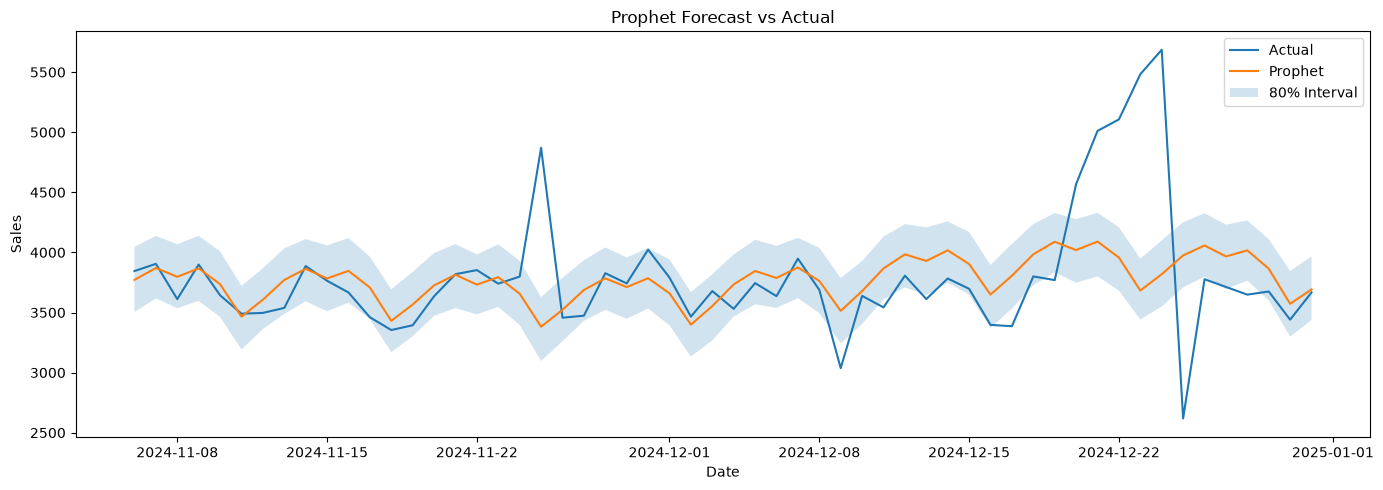

In [75]:
# Plot prophet forecast
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(prophet_test["ds"], prophet_test["y"], label="Actual")
ax.plot(prophet_forecast.index, prophet_forecast["yhat"], label="Prophet")
ax.fill_between(prophet_forecast.index, prophet_forecast["yhat_lower"], prophet_forecast["yhat_upper"],
               alpha=0.2, label="80% Interval")

ax.set_title("Prophet Forecast vs Actual")
ax.set_xlabel("Date")
ax.set_ylabel("Sales")
ax.legend()

plt.tight_layout()
plt.show()

In [76]:
# Find 10 worst days
prophet_errors = pd.DataFrame({
    "actual": prophet_test.set_index("ds")["y"],
    "forecast": prophet_forecast["yhat"]
})

prophet_errors["absolute_error"] = (prophet_errors["actual"] - prophet_errors["forecast"]).abs()

worst_10_days = prophet_errors.sort_values(
    "absolute_error", ascending=False
).head(10)

worst_10_days.round(0)

,actual,forecast,absolute_error
ds,,,
2024-12-24,5686.0,3819.0,1867.0
2024-12-23,5483.0,3683.0,1800.0
2024-11-25,4871.0,3382.0,1489.0
2024-12-25,2618.0,3975.0,1357.0
2024-12-22,5107.0,3957.0,1149.0
2024-12-21,5011.0,4090.0,921.0
2024-12-20,4569.0,4019.0,550.0
2024-12-09,3037.0,3514.0,476.0
2024-12-17,3386.0,3806.0,420.0


In [77]:
# Look at months
worst_10_days["month"] = worst_10_days.index.month
worst_10_days["day"] = worst_10_days.index.day


worst_10_days[["actual", "forecast", "absolute_error", "month", "day"]].round(0)

,actual,forecast,absolute_error,month,day
ds,,,,,
2024-12-24,5686.0,3819.0,1867.0,12,24
2024-12-23,5483.0,3683.0,1800.0,12,23
2024-11-25,4871.0,3382.0,1489.0,11,25
2024-12-25,2618.0,3975.0,1357.0,12,25
2024-12-22,5107.0,3957.0,1149.0,12,22
2024-12-21,5011.0,4090.0,921.0,12,21
2024-12-20,4569.0,4019.0,550.0,12,20
2024-12-09,3037.0,3514.0,476.0,12,9
2024-12-17,3386.0,3806.0,420.0,12,17


**Conclusion -->**
* The largest Prophet errors are concentrated around the December Christmas period.
* Yearly and weekly seasonality can learn repeating patterns, but they cannot fully explain a special event such as an unusual Christmas effect unless that information is explicitly provided to the model.

## **TASK 05 — Add holidays**

In [78]:
christmas_days = pd.to_datetime([
    "2021-12-25", "2022-12-25", "2023-12-25",
    "2024-12-25"
])

holidays = pd.DataFrame({
    "holiday":"Christmas",
    "ds": christmas_days,
    "lower_window": -1,
    "upper_window": 1
})

holidays

,holiday,ds,lower_window,upper_window
0,Christmas,2021-12-25,-1,1
1,Christmas,2022-12-25,-1,1
2,Christmas,2023-12-25,-1,1
3,Christmas,2024-12-25,-1,1


In [79]:
# Prophet with holidays
prophet_holiday_model = Prophet(yearly_seasonality=True, weekly_seasonality=True,
                               daily_seasonality=False, interval_width=0.80, holidays=holidays)
prophet_holiday_model.fit(prophet_train)

# Forecast
future_holiday = prophet_holiday_model.make_future_dataframe(
    periods=len(test), freq="D"
)

holiday_forecast_all = prophet_holiday_model.predict(future_holiday)

holiday_forecast = holiday_forecast_all[
    holiday_forecast_all["ds"].isin(prophet_test["ds"])
].copy()
holiday_forecast = holiday_forecast.set_index("ds")

holiday_mae = mean_absolute_error(
    prophet_test.set_index("ds")["y"],
    holiday_forecast["yhat"]
)

print("Prophet without holidays MAE:",
     round(prophet_mae, 2))
print("Prophet with holidays MAE:",
     round(holiday_mae, 2))

Prophet without holidays MAE: 299.38
Prophet with holidays MAE: 234.48


In [80]:
# Percentage Improvement
holiday_improvement = ((prophet_mae - holiday_mae) / prophet_mae) * 100

print("Improvement from holidays:",
     round(holiday_improvement, 2),"%")

Improvement from holidays: 21.68 %


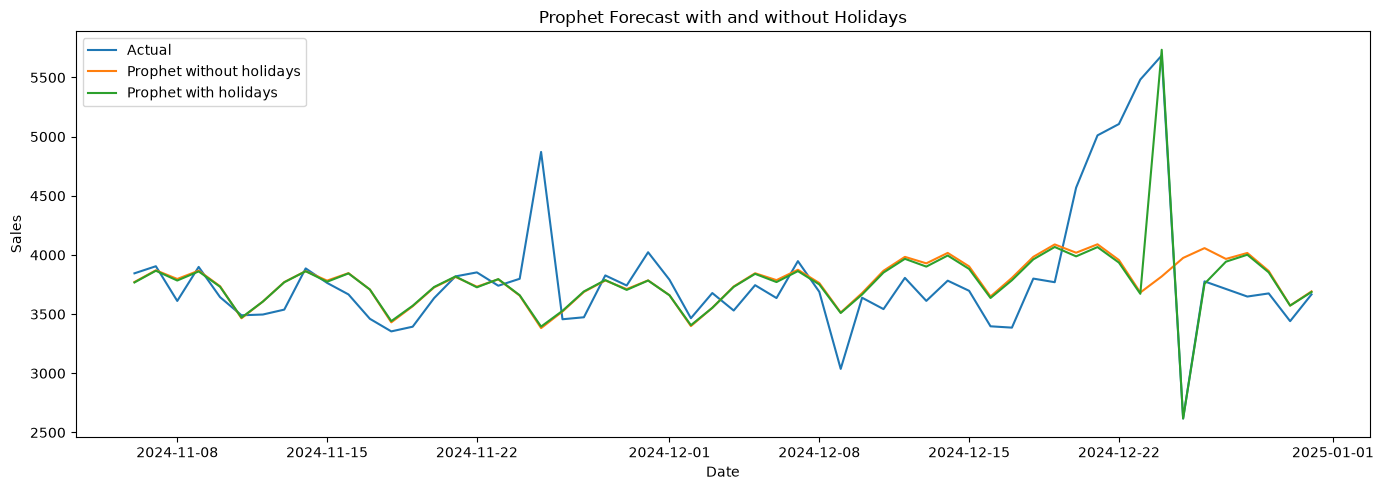

In [81]:
# Plot both Forecasts
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(prophet_test["ds"], prophet_test["y"], label="Actual")
ax.plot(prophet_forecast.index, prophet_forecast["yhat"], label="Prophet without holidays")
ax.plot(holiday_forecast.index, holiday_forecast["yhat"], label="Prophet with holidays")

ax.set_title("Prophet Forecast with and without Holidays")
ax.set_xlabel("Date")
ax.set_ylabel("Sales")
ax.legend()

plt.tight_layout()
plt.show()

In [82]:
# Compare with holiday windows 
window_results = []

for lower_window, upper_window in [
    (0, 0),
    (-1, 1),
    (-2, 2),
    (-3, 3),
]:
    holiday_temp = pd.DataFrame({
        "holiday": "Christmas",
        "ds": christmas_days,
        "lower_window": lower_window,
        "upper_window": upper_window
    })

    model = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False,
                   holidays=holiday_temp)
    model.fit(prophet_train)

    future_temp = model.make_future_dataframe(periods=len(test), freq="D")
    
    forecast_temp = model.predict(future_temp)
    forecast_temp = forecast_temp[forecast_temp["ds"].isin(prophet_test["ds"])].set_index("ds")

    mae = mean_absolute_error(prophet_test.set_index("ds")["y"],
                             forecast_temp["yhat"])

    window_results.append({
        "lower_window": lower_window,
        "upper_window": upper_window,
        "MAE": mae
    })

window_comparison = pd.DataFrame(window_results).sort_values("MAE")

window_comparison.round(2)

,lower_window,upper_window,MAE
3,-3,3,158.59
2,-2,2,193.41
1,-1,1,234.48
0,0,0,285.32


**Conclusion -->**
* The best holiday window is the one with the lowest holdout MAE.
* If widening the holiday window decreases MAE, the holiday effect extends beyond Christmas Day. If it increases MAE, the wider window is adding unnecessary flexibility.

## **TASK 06 — Components and uncertainty**

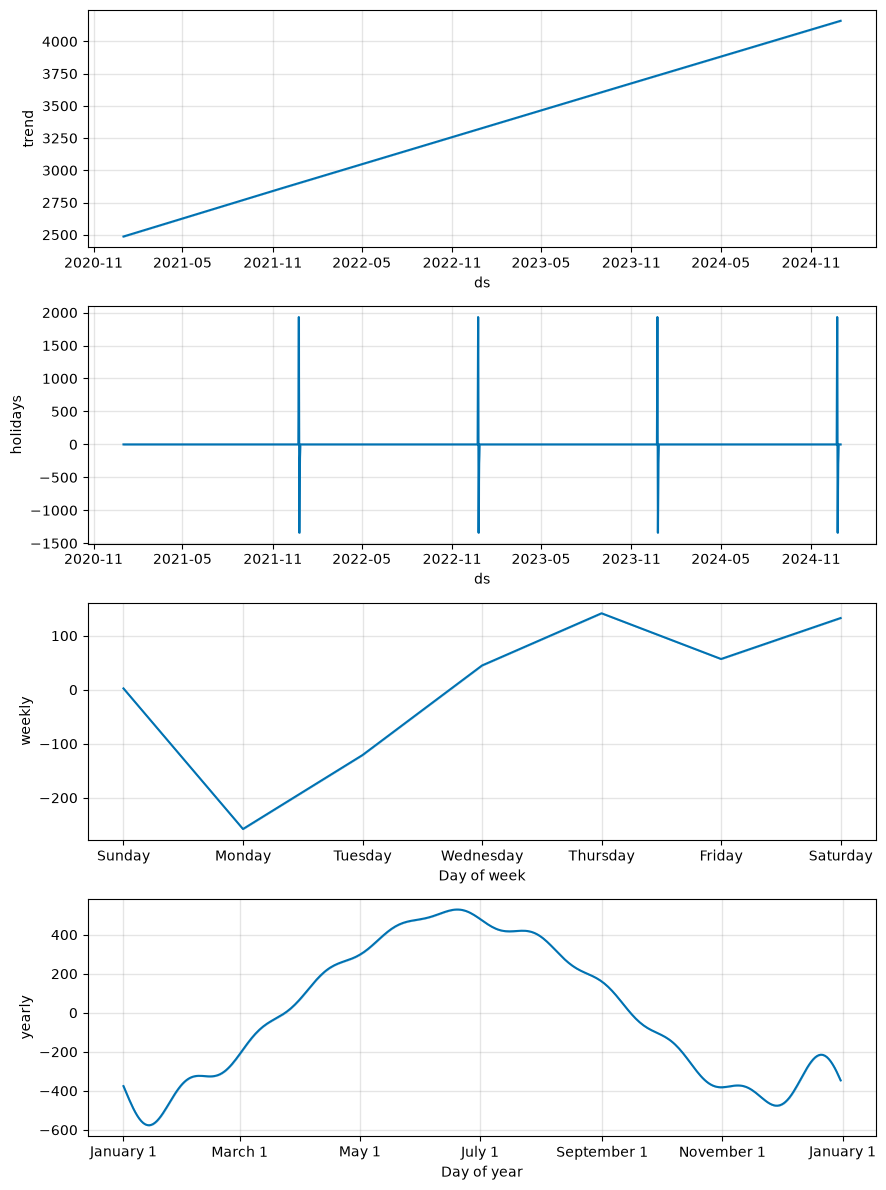

In [83]:
fig = prophet_holiday_model.plot_components(holiday_forecast_all)

plt.show()

**Explanation -->**
* The trend component shows the estimated long-term movement in sales.
* The weekly component shows the repeating pattern across days of the week.
* The yearly component shows the repeating pattern across the year.
* The holiday component shows the estimated additional effect associated with Christmas.

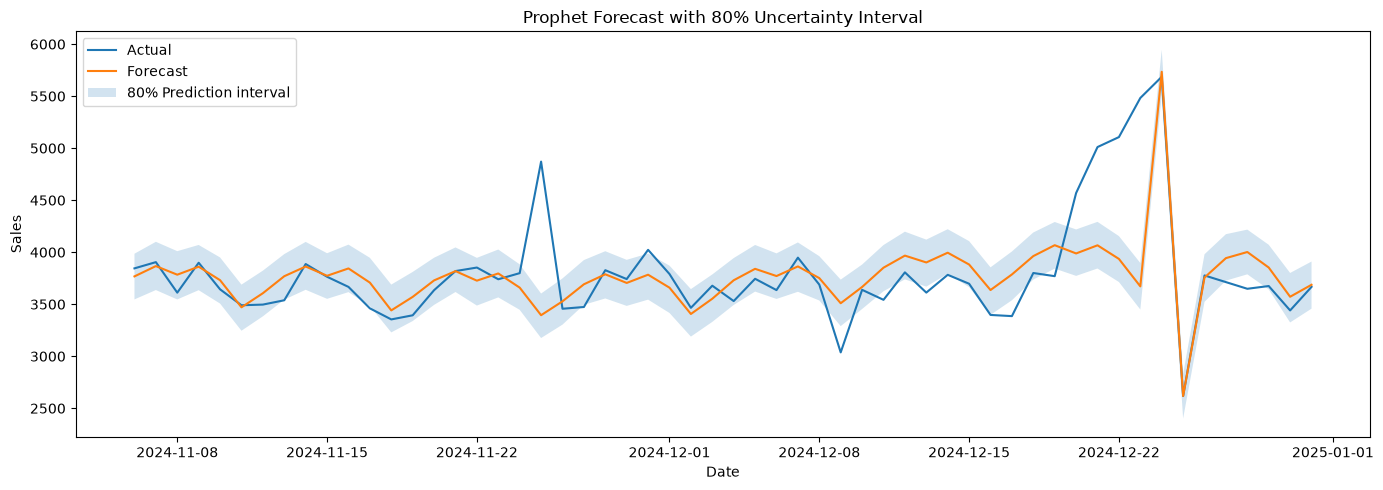

In [84]:
# 80% uncertainty interval
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(prophet_test["ds"], prophet_test["y"], label="Actual")
ax.plot(holiday_forecast.index, holiday_forecast["yhat"], label="Forecast")
ax.fill_between(holiday_forecast.index, holiday_forecast["yhat_lower"],
               holiday_forecast["yhat_upper"], alpha=0.2, label="80% Prediction interval")

ax.set_title("Prophet Forecast with 80% Uncertainty Interval")
ax.set_xlabel("Date")
ax.set_ylabel("Sales")
ax.legend()

plt.tight_layout()
plt.show()

In [85]:
# Calculate Coverage
actual_values = prophet_test.set_index("ds")["y"]

inside_interval = (
    (actual_values >= holiday_forecast["yhat_lower"]) &
    (actual_values <= holiday_forecast["yhat_upper"])
)

coverage = inside_interval.mean()

print("80% internal coverage:", coverage.round(4))
print("Coverage Percentage:", round(coverage * 100, 2))

80% internal coverage: 0.6786
Coverage Percentage: 67.86


In [86]:
# Compare with 80%
if coverage >= 0.80:
    print("The interval contains at least 80% of actual values.")
else:
    print("The interval contains less than 80% of actual values.")

The interval contains less than 80% of actual values.


# **Part D — Evaluate across periods**
## **TASK 07 — A second holdout**

In [87]:
second_holdout_end = pd.Timestamp("2024-09-29")
second_holdout_start = second_holdout_end - pd.Timedelta(days=55)

second_train = df.loc[:second_holdout_start - pd.Timedelta(days=1)].copy()
second_test = df.loc[second_holdout_start:second_holdout_end].copy()

print("Second Training Period:")
print(second_train.index.min(), "to", second_train.index.max())

print("\nSecond Holdout:")
print(second_test.index.min(), "to", second_test.index.max())

print("\nRows:", len(second_test))

Second Training Period:
2021-01-01 00:00:00 to 2024-08-04 00:00:00

Second Holdout:
2024-08-05 00:00:00 to 2024-09-29 00:00:00

Rows: 56


In [88]:
# Second-Season naive baseline
second_baseline_fc = df["sales"].shift(7).loc[
    second_test.index
]
second_baseline_mae = mean_absolute_error(second_test["sales"], second_baseline_fc)

print("Second holdout seasonal naive MAE:", round(second_baseline_mae, 3))

Second holdout seasonal naive MAE: 128.043


In [89]:
# Second ARIMA
best_arima_order = tuple(best_mae_row["Order"])

second_arima_model = ARIMA(second_train["sales"], order=best_arima_order)
second_arima_result = second_arima_model.fit()

second_arima_fc = (second_arima_result.forecast(steps=len(second_test)))
second_arima_mae = mean_absolute_error(second_test["sales"], second_arima_fc)

print("Second ARIMA MAE", round(second_arima_mae, 2))

Second ARIMA MAE 243.57


In [90]:
# Second SARIMA
best_sarima_order = tuple(best_sarima_row["Seasonal_order"])

second_sarima_model = SARIMAX(second_train["sales"], order=(1, 1, 1),
                             seasonal_order=best_sarima_order, enforce_stationarity=False,
                             enforce_invertibility=False)
second_sarima_result = second_sarima_model.fit(disp=False)

second_sarima_fc = (second_sarima_result.forecast(steps=len(second_test)))
second_sarima_mae = mean_absolute_error(second_test["sales"], second_sarima_fc)

print("Second SARIMA MAE:", round(second_sarima_mae, 2))

Second SARIMA MAE: 267.13


In [91]:
# Second Prophet
second_prophet_train = (second_train.reset_index()[
    ["date", "sales"]
].rename(columns={
    "date": "ds",
    "sales": "y"
}))

second_prophet_model = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False,
                              holidays=holidays)
second_prophet_model.fit(second_prophet_train)

second_future = second_prophet_model.make_future_dataframe(
    periods=(len(second_test)), freq="D"
)
second_prophet_all = second_prophet_model.predict(second_future)

second_prophet_forecast = (second_prophet_all[second_prophet_all["ds"].isin(
    second_test.index
)].set_index("ds"))

second_prophet_mae = mean_absolute_error(second_test["sales"],
                                        second_prophet_forecast["yhat"])


print("Second Prophet MAE:", round(second_prophet_mae, 3))

Second Prophet MAE: 91.905


In [92]:
# Two period comparison table
comparison_table = pd.DataFrame({
    "Final 8 Weeks": [baseline_mae, arima_mae, sarima_mae, holiday_mae],
    "Ordinary 8 Weeks": [second_baseline_mae, second_arima_mae, second_sarima_mae,
                        second_prophet_mae]
}, index=["Seasonal Naive", "ARIMA", "SARIMA", "Prophet + Holidays"])

comparison_table.round(2)

,Final 8 Weeks,Ordinary 8 Weeks
Seasonal Naive,446.42,128.04
ARIMA,301.37,243.57
SARIMA,285.44,267.13
Prophet + Holidays,234.48,91.91


In [93]:
# Winners
print("First Holdout winner:",
     comparison_table["Final 8 Weeks"].idxmin())

print("\nOrdinary Holdout Winner:",
     comparison_table["Ordinary 8 Weeks"].idxmin())

First Holdout winner: Prophet + Holidays

Ordinary Holdout Winner: Prophet + Holidays


**Conclusion -->**
* Prophet should not be described as simply better or worse without mentioning the test period. Its performance can change between an ordinary period and a holiday-heavy period.
* This demonstrates why reporting one forecasting result from one holdout window can give an incomplete picture of model reliability.

## **TASK 08 — Backtest properly**

In [94]:
# Select best model
average_results = comparison_table.mean(axis=1).sort_values()

print(average_results)

best_model_name = average_results.index[0]

print("\nBest model across the two holdouts:",
     best_model_name)

Prophet + Holidays    163.194349
ARIMA                 272.471125
SARIMA                276.281818
Seasonal Naive        287.233795
dtype: float64

Best model across the two holdouts: Prophet + Holidays


In [95]:
# Rolling origin backtest
fc_horizon = 28
number_of_windows = 6

end_points = []

first_possible_end = pd.Timestamp("2024-05-31")
last_possible_end = (df.index.max() - pd.Timedelta(days=fc_horizon))

current_end = first_possible_end

while (current_end <= last_possible_end and
      len(end_points) < number_of_windows):
    end_points.append(current_end)
    current_end += pd.Timedelta(days=28)

print("Backtest windows:")
for date in end_points:
    print(date)

Backtest windows:
2024-05-31 00:00:00
2024-06-28 00:00:00
2024-07-26 00:00:00
2024-08-23 00:00:00
2024-09-20 00:00:00
2024-10-18 00:00:00


In [96]:
# Run the backtest
backtest_results = []

for window_number, train_end in enumerate(end_points, start=1):
    train_bt = df.loc[:train_end]
    test_start = train_end + pd.Timedelta(days=1)
    test_end = train_end + pd.Timedelta(days=fc_horizon)
    test_bt = df.loc[test_start:test_end]

    if len(test_bt) < fc_horizon:
        continue

    # seasonal naive
    baseline_bt_fc = (df["sales"].shift(7).loc[test_bt.index])
    baseline_bt_mae = mean_absolute_error(test_bt["sales"], baseline_bt_fc)

    # Best model
    if best_model_name == "ARIMA":
        model_bt = ARIMA(train_bt["sales"], order=best_arima_order)
        result_bt = model_bt.fit()
        fc_bt = result_bt.forecast(steps=fc_horizon)

    elif best_model_name == "SARIMA":
        model_bt = SARIMAX(train_bt["sales"], order=(1, 1, 1), seasonal_order=best_sarima_order,
                          enforce_invertibility=False, enforce_stationarity=False)
        result_bt = model_bt.fit(disp=False)
        fc_bt = result_bt.forecast(steps=fc_horizon)

    else:
        train_prophet_bt = (train_bt.reset_index()[["date", "sales"]].rename(columns={
            "date": "ds",
            "sales": "y"
        }))

        model_bt = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False,
                          holidays=holidays)
        model_bt.fit(train_prophet_bt)

        future_bt = model_bt.make_future_dataframe(periods=fc_horizon, freq="D")
        fc_bt_all = model_bt.predict(future_bt)
        fc_bt = (fc_bt_all.tail(fc_horizon)["yhat"].values)


    model_bt_mae = mean_absolute_error(test_bt["sales"], fc_bt)

    backtest_results.append({
        "window": window_number,
        "train_end": train_end,
        "test_start": test_start,
        "test_end": test_end,
        "model_mae": model_bt_mae,
        "baseline_mae": baseline_bt_mae
    })



backtest_df = pd.DataFrame(backtest_results)

backtest_df.round(3)

,window,train_end,test_start,test_end,model_mae,baseline_mae
0,1,2024-05-31,2024-06-01,2024-06-28,84.761,111.784
1,2,2024-06-28,2024-06-29,2024-07-26,89.087,136.598
2,3,2024-07-26,2024-07-27,2024-08-23,75.562,117.272
3,4,2024-08-23,2024-08-24,2024-09-20,91.815,132.032
4,5,2024-09-20,2024-09-21,2024-10-18,114.422,190.058
5,6,2024-10-18,2024-10-19,2024-11-15,67.508,104.783


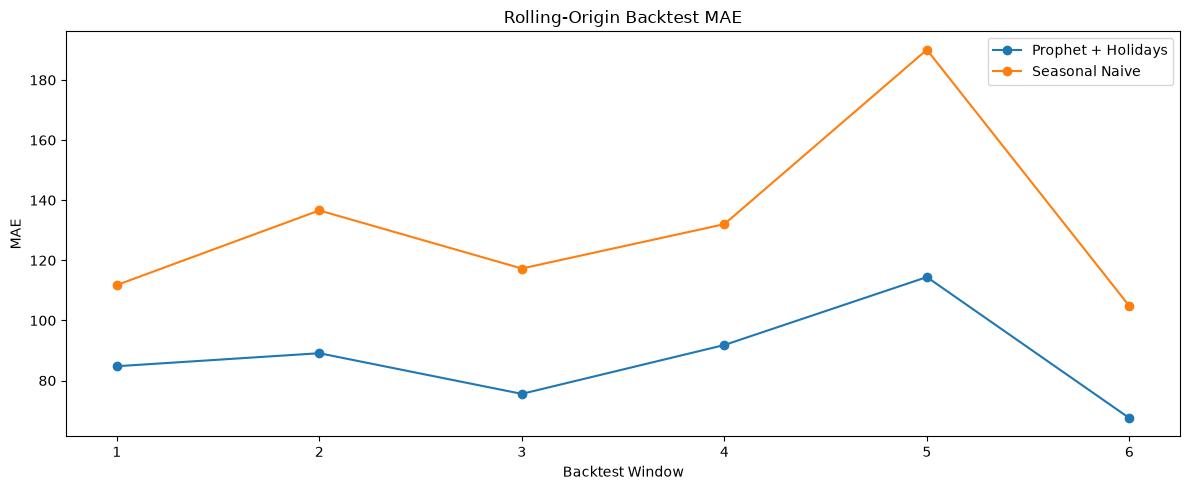

In [97]:
# plot MAE across windows
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(backtest_df["window"], backtest_df["model_mae"], marker="o", label=best_model_name)
ax.plot(backtest_df["window"], backtest_df["baseline_mae"], marker="o", label="Seasonal Naive")

ax.set_title("Rolling-Origin Backtest MAE")
ax.set_xlabel("Backtest Window")
ax.set_ylabel("MAE")
ax.legend()

plt.tight_layout()
plt.show()

In [98]:
# Mean and worst-case MAE
model_mean_mae = backtest_df["model_mae"].mean()
model_worst_mae = backtest_df["model_mae"].max()

baseline_mean_mae = backtest_df["baseline_mae"].mean()
baseline_worst_mae = backtest_df["baseline_mae"].max()

print("Model")
print("-" * 6)
print("Mean MAE:", round(model_mean_mae, 2))
print("Worst MAE:", round(model_worst_mae, 2))

print("\nSeasonal Naive")
print("-" * 15)
print("Mean MAE:", round(baseline_mean_mae, 2))
print("Worst MAE:", round(baseline_worst_mae, 2))

Model
------
Mean MAE: 87.19
Worst MAE: 114.42

Seasonal Naive
---------------
Mean MAE: 132.09
Worst MAE: 190.06


In [99]:
# Count how often model wins
model_wins = (backtest_df["model_mae"] < backtest_df["baseline_mae"])

print("Model wins:", model_wins.sum(), "out of", len(model_wins), "windows")
print("Model wins consistently:", model_wins.all())

Model wins: 6 out of 6 windows
Model wins consistently: True


**Conclusion -->**
* Average performance and consistency are different questions.
* A model can have a lower average MAE while still losing badly in some forecast windows.
* For a system that runs every week, consistency is important because a model that frequently performs worse than the baseline creates unpredictable operational risk.

## **Final Results Summary**

In [100]:
final_summary = pd.DataFrame({
    "Method": ["Seasonal Naive", "ARIMA", "SARIMA", "Prophet + Holidays"],
    "Final Holdout MAE": [baseline_mae, arima_mae, sarima_mae, holiday_mae],
    "Second Holdout MAE": [second_baseline_mae, second_arima_mae, second_sarima_mae,
                          second_prophet_mae]
})

final_summary.round(3)

,Method,Final Holdout MAE,Second Holdout MAE
0,Seasonal Naive,446.425,128.043
1,ARIMA,301.369,243.573
2,SARIMA,285.438,267.126
3,Prophet + Holidays,234.484,91.905
